In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 548.5 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=5a2316be4b20abea8fa0a690972283a071e6f23ac470faddd36b5a7a26d7ca7d
  Stored in directory: /root/.cache/pip/wheels/fa/f7/53/a55a8a56668a6fe0199e0e02b6e0ae3007ec35cdf6e4c25df7
Successfully built factor_analyzer


En este estudio se aplica PCA a una base de datos reales, conocida como Wine Quality Dataset , la cual contiene mediciones fisicoquímicas de muestras de vino tinto. Esta base incluye 11 variables numéricas como acidez, pH, sulfatos y concentración de alcohol, además de una variable de salida que representa la calidad del vino evaluada por expertos.

El objetivo principal de este análisis es:

Identificar si existen variables altamente correlacionadas entre sí.

Reduzca la dimensionalidad del conjunto de datos a un número menor de componentes que expliquen la mayor parte de la variación.

Interpretar visualmente las relaciones entre las variables mediante gráficos como el círculo unitario , el gráfico de sedimentación y la varianza explicada .



Acidez fija : concentración de ácidos no volátiles presentes en el vino, principalmente ácido tartárico.

acidez volátil: concentración de ácidos volátiles, como el ácido acético, que pueden producir aromas no deseados si están en niveles elevados.

ácido cítricocítricopequeñas: cantidad de ácido cítrico, que contribuye al sabor fresco del vino. En pequeñas cantidades puede mejorar el sabor general.

azúcar residual: cantidad de azúcar que queda después de la fermentación. Niveles elevados se asocian a vinos más dulces.

cloruros : contenido de cloruro de sodio en el vino. Altas concentraciones pueden afectar negativamente el sabor.

dióxido de azufre librede azufre: cantidad de dióxido de azufre libre, utilizado como agente antimicrobiano y antioxidante. Es la fracción activa del dióxido de azufre añadido.

dióxido de azufre total: suma del dióxido de azufre libre y combinado. En exceso puede afectar el aroma y provocar reacciones en personas sensibles.

densidad : densidad del vino, influenciada por el contenido de azúcar y alcohol.

pH: medida de acidez del vino. Los valores más bajos indican mayor acidez.

sulfatos : concentración de compuestos sulfatados, los cuales actúan como conservantes y pueden influir en las características sensoriales del vino.

alcohol : contenido de alcohol expresado como porcentaje en volumen. Influye en el cuerpo y la percepción sensorial del vino.

calidad: puntuación asignada al vino por catadores expertos, en una escala ordinal. Esta variable representa una evaluación sensorial general.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer.rotator import Rotator
from sklearn.datasets import fetch_openml

# Cargar base de datos real: vino tinto (16 variables numéricas)
wine = fetch_openml(name='wine-quality-red', version=1, as_frame=True)
df = wine.frame
df_numeric = df.select_dtypes(include=[np.number])

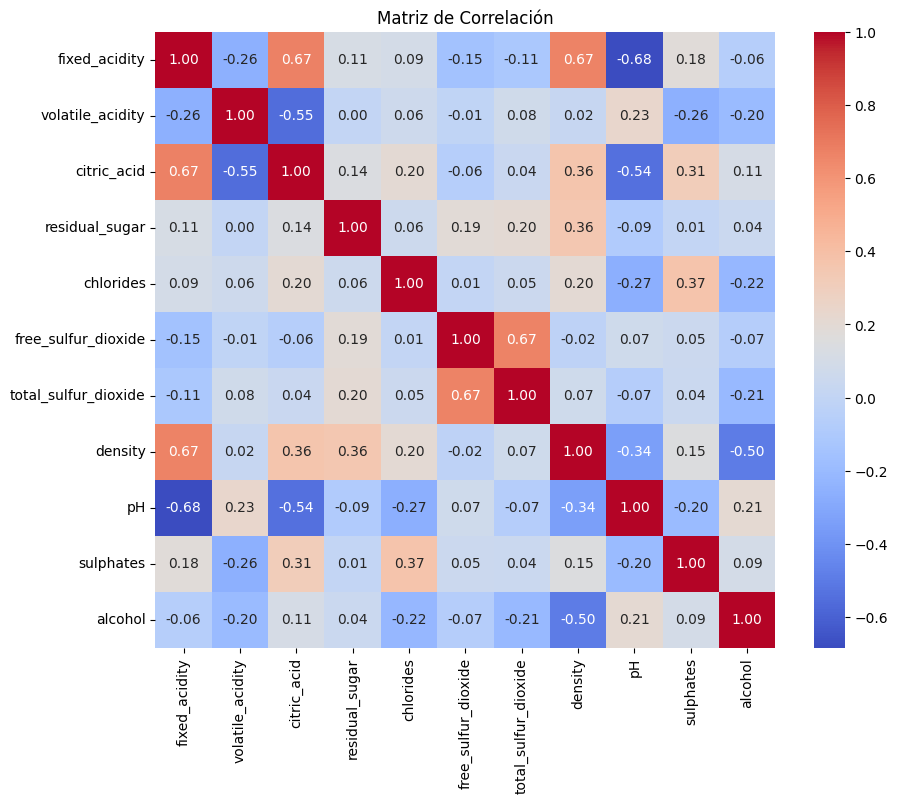

In [ ]:
# Escalar los datos
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

# Matriz de correlación
correlation_matrix = pd.DataFrame(scaled_data, columns=df_numeric.columns).corr()

# Graficar matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

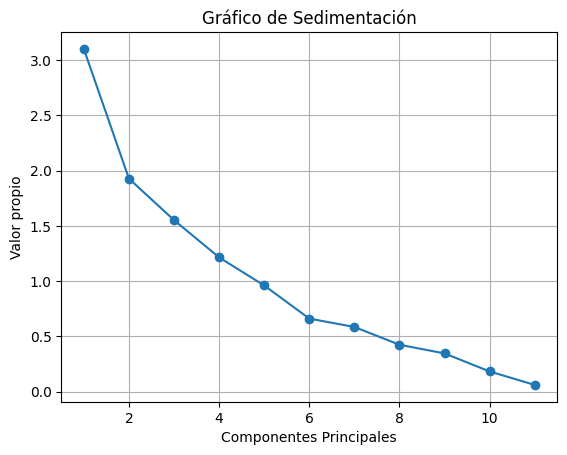

In [ ]:
# PCA completo
pca = PCA()
pca_fit = pca.fit(scaled_data)
pca_components = pca.transform(scaled_data)

# Valores y vectores propios
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

# Scree plot
plt.figure()
plt.plot(np.arange(1, len(eigenvalues)+1), eigenvalues, 'o-', label='Eigenvalues')
plt.xlabel('Componentes Principales')
plt.ylabel('Valor propio')
plt.title('Gráfico de Sedimentación')
plt.grid(True)
plt.show()

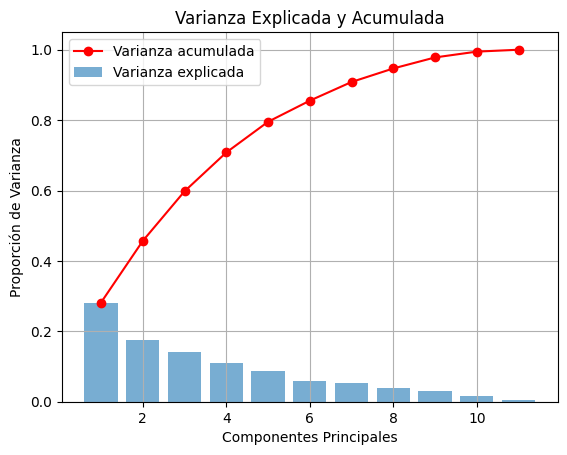

In [ ]:
explained_var = pca.explained_variance_ratio_

plt.figure()
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Varianza explicada')
plt.plot(range(1, len(explained_var)+1), np.cumsum(explained_var), marker='o', color='r', label='Varianza acumulada')
plt.xlabel('Componentes Principales')
plt.ylabel('Proporción de Varianza')
plt.legend()
plt.title('Varianza Explicada y Acumulada')
plt.grid(True)
plt.show()

In [ ]:
# Selección de 5 componentes
n_components = 5
pca_reduced = PCA(n_components=n_components)
reduced_data = pca_reduced.fit_transform(scaled_data)

# Cargas factoriales (loadings)
loadings = pd.DataFrame(pca_reduced.components_.T, index=df_numeric.columns,
                        columns=[f'PC{i+1}' for i in range(n_components)])

# Rotación Varimax
rotator = Rotator()
rotated = rotator.fit_transform(loadings.values)
rotated_loadings = pd.DataFrame(rotated, index=df_numeric.columns, columns=loadings.columns)


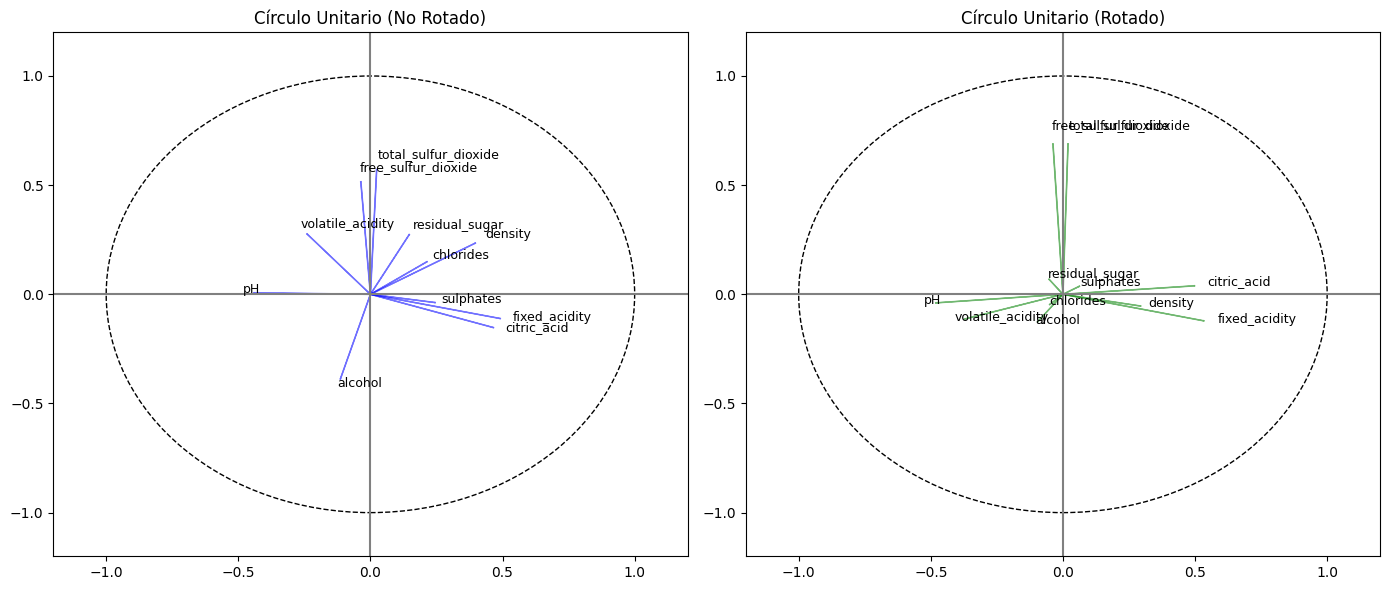

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# No rotado
for i in range(len(loadings)):
    axs[0].arrow(0, 0, loadings.iloc[i, 0], loadings.iloc[i, 1], color='blue', alpha=0.5)
    axs[0].text(loadings.iloc[i, 0]*1.1, loadings.iloc[i, 1]*1.1, loadings.index[i], fontsize=9)
axs[0].add_artist(plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--'))
axs[0].set_xlim(-1.2, 1.2)
axs[0].set_ylim(-1.2, 1.2)
axs[0].axhline(0, color='grey')
axs[0].axvline(0, color='grey')
axs[0].set_title("Círculo Unitario (No Rotado)")

# Rotado
for i in range(len(rotated_loadings)):
    axs[1].arrow(0, 0, rotated_loadings.iloc[i, 0], rotated_loadings.iloc[i, 1], color='green', alpha=0.5)
    axs[1].text(rotated_loadings.iloc[i, 0]*1.1, rotated_loadings.iloc[i, 1]*1.1, rotated_loadings.index[i], fontsize=9)
axs[1].add_artist(plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--'))
axs[1].set_xlim(-1.2, 1.2)
axs[1].set_ylim(-1.2, 1.2)
axs[1].axhline(0, color='grey')
axs[1].axvline(0, color='grey')
axs[1].set_title("Círculo Unitario (Rotado)")

plt.tight_layout()
plt.show()

In [ ]:
# Mostrar tabla de agrupamiento
print("Matriz de cargas factoriales rotadas:")
display(rotated_loadings.style.background_gradient(cmap="viridis"))


Matriz de cargas factoriales rotadas:


,PC1,PC2,PC3,PC4,PC5
fixed_acidity,0.531199,-0.121123,-0.083411,-0.099822,0.112366
volatile_acidity,-0.371038,-0.113045,-0.453120,0.025414,0.180673
citric_acid,0.495960,0.038688,0.221001,0.079205,0.043662
residual_sugar,-0.051435,0.067523,0.097976,0.004790,0.873965
chlorides,-0.048759,-0.045564,-0.207683,0.729634,0.013108
free_sulfur_dioxide,-0.037584,0.686614,0.050168,-0.000113,0.027892
total_sulfur_dioxide,0.019231,0.686908,-0.085119,-0.005370,0.004614
density,0.292146,-0.053403,-0.393632,-0.003366,0.371025
pH,-0.478955,-0.039073,0.141386,-0.042966,0.120414
sulphates,0.060622,0.035837,0.198665,0.669853,-0.009482


##  Conclusión general del análisis de componentes rotados (Varimax)

Tras aplicar la rotación Varimax al análisis de componentes principales, logramos identificar **5 dimensiones latentes** dentro del conjunto de variables físico-químicas del vino. Estas dimensiones nos permiten interpretar de manera más clara la estructura de los datos y agrupar las variables en factores con significado enológico:

| Componente | Tema interpretado           | Variables principales                                 |
|------------|-----------------------------|-------------------------------------------------------|
| **PC1**    | Acidez estructural          | `fixed_acidity`, `citric_acid`                        |
| **PC2**    | Conservación (sulfitos)     | `free_sulfur_dioxide`, `total_sulfur_dioxide`         |
| **PC3**    | Alcohol y cuerpo del vino   | `alcohol`                                              |
| **PC4**    | Minerales y amargor         | `chlorides`, `sulphates`                              |
| **PC5**    | Dulzura residual            | `residual_sugar`                                      |

- Cada variable muestra su mayor carga en un solo componente, lo que facilita su **asignación temática**.
- Este patrón es una ventaja de la **rotación Varimax**, que redistribuye las cargas para mejorar la interpretación.
- La matriz rotada sugiere la existencia de **subconjuntos coherentes de variables** que podrían usarse para clasificar tipos de vino o predecir características sensoriales.

Esta representación es especialmente útil para construir modelos de clasificación, agrupamiento o interpretación en estudios de calidad y estilo del vino.
